<h1> Imports & Installs </h1>

In [1]:
!pip install scikit-image


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy import ndimage
from skimage.feature import blob_log
from skimage.color import rgb2gray

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)

<h1> Loading Image </h1>

In [3]:
# For now, the Image Path must be set.
IMAGE_PATH = "images/edited image.jpg"  

try:
    image = np.array(Image.open(IMAGE_PATH).convert("RGB"))
    print(f"Loaded image: {IMAGE_PATH}, shape={image.shape}")
except FileNotFoundError:
    image = None
    print("No file found at IMAGE_PATH. Run the next cell to generate a synthetic starfield instead.")

Loaded image: images/edited image.jpg, shape=(2268, 4032, 3)


# Normalizing / Greyscale the Image
<li> Note: Most of these steps can be substitute via Joey's Algorithm handling the Filtering / Pre-Processing Section</li>

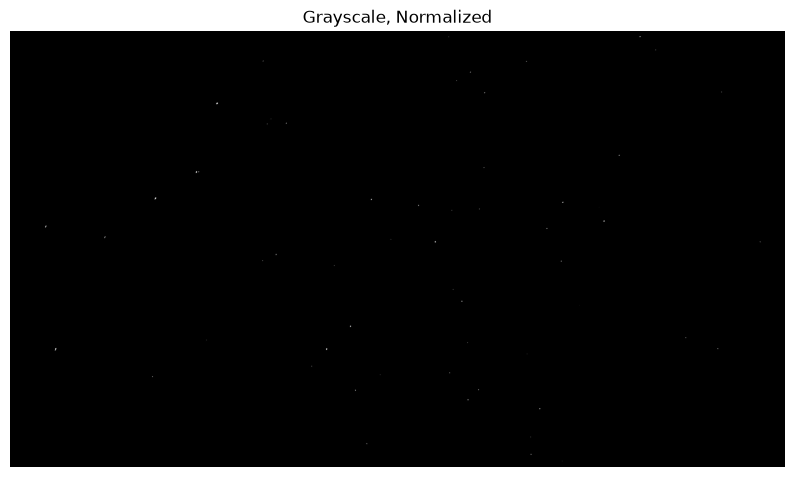

In [4]:
gray = rgb2gray(image)  # values now in range [0, 1]

# Normalize to use the full 0-1 range, in case the image doesn't already
gray_norm = (gray - gray.min()) / (gray.max() - gray.min())

plt.imshow(gray_norm, cmap='gray')
plt.title("Grayscale, Normalized")
plt.axis('off')
plt.show()

<h1> Filtering Phase </h1>

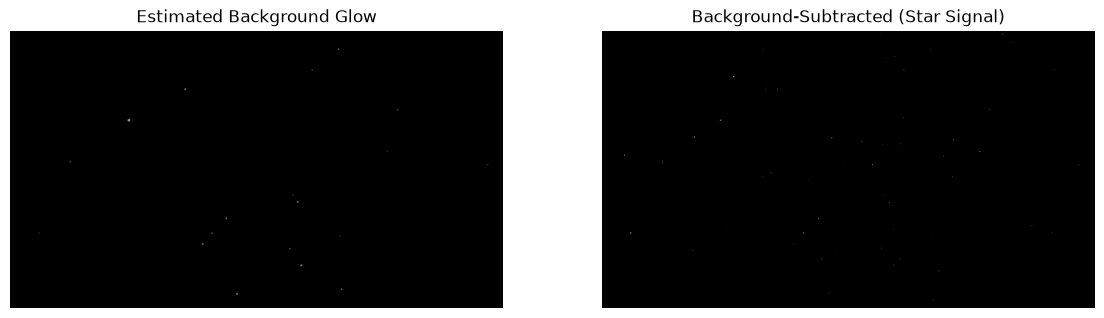

In [5]:
# A large median filter smooths out small bright dots (stars) but keeps
# the slow-varying background glow intact.
background_estimate = ndimage.median_filter(gray_norm, size=25)

# Subtracting it leaves mostly just the sharp, star-like features
star_signal = gray_norm - background_estimate
star_signal = np.clip(star_signal, 0, None)  # discard negative dips

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(background_estimate, cmap='gray')
axes[0].set_title("Estimated Background Glow")
axes[0].axis('off')
axes[1].imshow(star_signal, cmap='gray')
axes[1].set_title("Background-Subtracted (Star Signal)")
axes[1].axis('off')
plt.show()

<h1> Candidate Star Detection via Blobs</h1>

In [6]:
blobs = blob_log(
    star_signal,
    min_sigma=1,
    max_sigma=4,
    num_sigma=8,
    threshold=0.05
)

# blob_log returns (y, x, sigma) for each detection.
# Convert sigma to an approximate display radius.
blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

print(f"Detected {len(blobs)} candidate stars before filtering.")

Detected 62 candidate stars before filtering.


In [7]:
MIN_BRIGHTNESS = 0.15   # minimum normalized pixel value to count as a real star
EDGE_MARGIN = 5         # pixels away from the border required

filtered_blobs = []
for (y, x, r) in blobs:
    y, x = int(round(y)), int(round(x))
    if not (EDGE_MARGIN <= y < gray_norm.shape[0] - EDGE_MARGIN):
        continue
    if not (EDGE_MARGIN <= x < gray_norm.shape[1] - EDGE_MARGIN):
        continue
    brightness = gray_norm[y, x]
    if brightness < MIN_BRIGHTNESS:
        continue
    filtered_blobs.append((y, x, r, brightness))

print(f"{len(filtered_blobs)} stars remain after filtering (from {len(blobs)} candidates).")

62 stars remain after filtering (from 62 candidates).


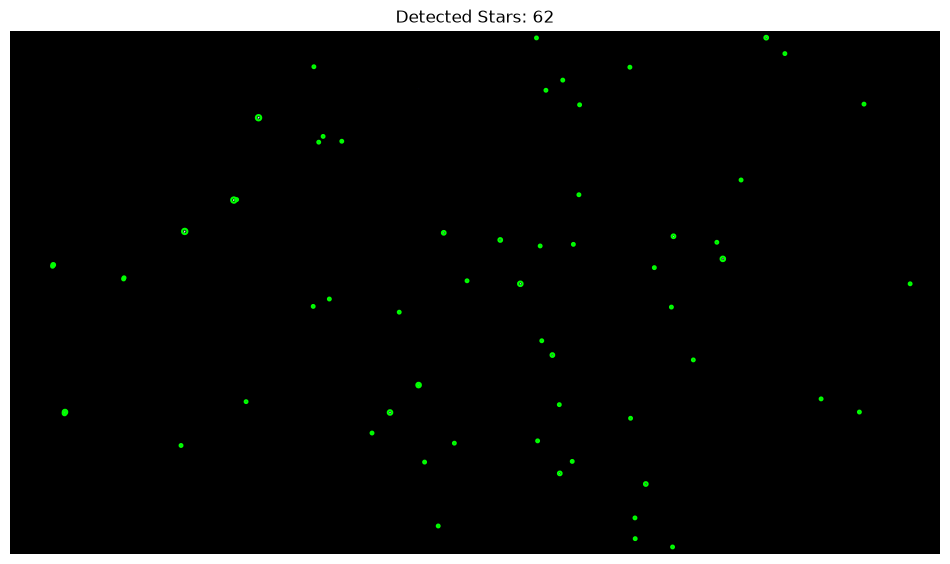

In [8]:
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Detected Stars: {len(filtered_blobs)}")
ax.axis('off')

for (y, x, r, brightness) in filtered_blobs:
    circle = patches.Circle((x, y), radius=max(r * 3, 6), fill=False,
                             edgecolor='lime', linewidth=1.5)
    ax.add_patch(circle)

plt.show()

In [66]:
# Displaying the Star Candidates in a dataframe
import pandas as pd

results_df = pd.DataFrame(
    filtered_blobs, columns=["y (row)", "x (col)", "size (sigma)", "brightness (0-1)"]
).sort_values("y (row)", ascending=True).reset_index(drop=True)

results_df

,y (row),x (col),size (sigma),brightness (0-1)
0,29,3278,2.626397,0.977907
1,30,2282,1.414214,0.969167
2,98,3359,1.414214,0.988333
3,155,1317,1.414214,0.974167
4,157,2687,2.020305,0.976667
...,...,...,...,...
57,1964,2756,2.626397,0.995000
58,2111,2709,1.414214,0.977500
59,2146,1856,2.020305,0.964167
60,2201,2710,2.020305,0.965833


# KNN Section
<p> Pathways (For Latitide)</p>
<li> Identification through North Star (Exclusive to North Hemisphere)
    <li>
        asd
    </li>
<li> Identification Using Southern Cross (Exclusive to South Hemisphere)
<li> Identification Using Rising and Setting Positions of Constellations
</li>


In [10]:
class Star_KNN:
  def __init__(self, k):
    self.k = k

  #Train Model on Images
  def fit(self, X_train, y_train):
    return

  #Euclidean Distance Function
  def Euclidean_distance(self, x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))

  #Manhattan Distance Function
  def Manhattan_distance(self, x1, x2):
    return np.sum(np.abs(x1 - x2))

  #Minkowski Distance Function
  def Minkowski_distance(self, x1, x2, p):
    return (np.sum(np.abs(x1- x2)**p))**(1/p)


In [102]:
#Clustering the Points
import pandas as pd
from sklearn.cluster import DBSCAN
data = results_df
location_x, location_y = data['x (col)'], data['y (row)']
test_df = pd.DataFrame({ data.columns[0] : location_x,
                    data.columns[1] : location_y})
dfe = df[[data.columns[0], data.columns[1]]].values
db = DBSCAN(eps = 400.0, min_samples=2) #utilizing DBSCAN from scikit-learn for use of proof of concept
                                        #Ideally, we replace this later with a more appropiate model
test_df['cluster'] = db.fit_predict(dfe)
test_df
len(test_df)


62

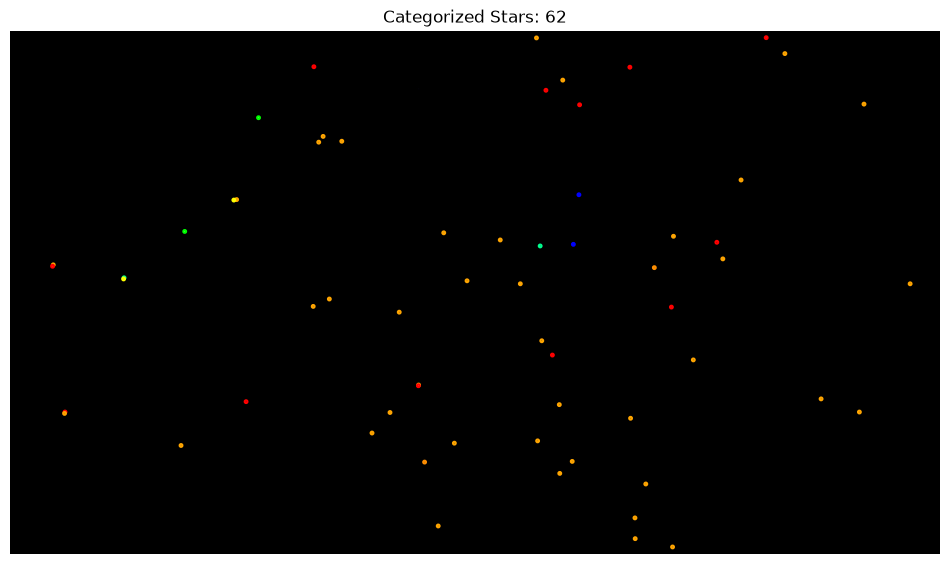

In [101]:
#SHowcasing the Clustered Points
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Categorized Stars: {len(filtered_blobs)}")
ax.axis('off')
colorcode = {
    -1 : 'lime',
    0 : 'red',
    1 : 'orange',
    2 : 'blue',
    3 : 'yellow',
    4 : '#00ff8f',
    5 : '#ff8e00'
}
for row in test_df.itertuples():
    circle = patches.Circle((row[1], row[2]), radius = max(r*3, 6), 
    fill = False, edgecolor = colorcode.get(row.cluster), linewidth = 1.5)
    ax.add_patch(circle)
plt.show()

In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

data = 

Model Accuracy:  0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

